# Architecture 3 v2 — Prompt Profiling Pipeline (Enhanced)

**Improvements over v1:**
1. **PCA Dimensionality Reduction** — 384-dim embeddings → 50 principal components
2. **Hand-Crafted Features** — 18 structural/linguistic features concatenated with PCA embeddings
3. **Ordinal Classification** — XGBClassifier predicting discrete score classes {0, 0.25, 0.5, 0.75, 1.0} instead of continuous regression
4. **Native Discrete Outputs** — No rounding needed; model outputs are inherently valid scores

**Pipeline:**  
Prompt text → MiniLM-L6-v2 (384d) → PCA (50d) + Hand-Crafted Features (18d) → StandardScaler → MultiOutputClassifier(XGBClassifier) → predicts D1, D2, D3, D5 as ordinal classes → D4 Rule Engine → Complexity Score → Tier

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, classification_report, accuracy_score
)
from sklearn.metrics.pairwise import cosine_similarity

from xgboost import XGBClassifier
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)

print("All imports successful.")

All imports successful.


---
## Helper Functions

Core utility functions used throughout the pipeline:
- `complexity_score()` — weighted composite of all five dimensions
- `get_tier()` — maps complexity score → T1/T2/T3
- `get_d4()` — rule-based D4 scoring
- `extract_handcrafted_features()` — structural/linguistic features from raw prompt text

**Ordinal mapping:**  
Scores `{0.0, 0.25, 0.50, 0.75, 1.0}` ↔ Classes `{0, 1, 2, 3, 4}`

In [2]:
# ── Score ↔ Class mappings ────────────────────────────────────────────────────
SCORE_TO_CLASS = {0.0: 0, 0.25: 1, 0.50: 2, 0.75: 3, 1.0: 4}
CLASS_TO_SCORE = {0: 0.0, 1: 0.25, 2: 0.50, 3: 0.75, 4: 1.0}


def complexity_score(d1, d2, d3, d4, d5):
    """Compute weighted complexity score from five dimension scores."""
    return (d1 * 0.35) + (d2 * 0.20) + (d3 * 0.20) + (d4 * 0.15) + (d5 * 0.10)


def get_tier(score):
    """Map a complexity score to a tier label."""
    if score < 0.40:
        return 'T1'
    elif score < 0.70:
        return 'T2'
    else:
        return 'T3'


def get_d4(prompt):
    """Rule-based D4 score using case-insensitive substring matching.

    Priority order (first match wins):
      1.0  → market research, competitive analysis, analyst report,
             industry trends, industry report
      0.75 → latest, recent, current, pricing, market,
             forecast, survey, compare vendors
      0.50 → compare, evaluate, benchmark, analysis, study
      0.0  → otherwise
    """
    text = prompt.lower()

    keywords_1 = ["market research", "competitive analysis", "analyst report",
                  "industry trends", "industry report"]
    if any(kw in text for kw in keywords_1):
        return 1.0

    keywords_075 = ["latest", "recent", "current", "pricing", "market",
                    "forecast", "survey", "compare vendors"]
    if any(kw in text for kw in keywords_075):
        return 0.75

    keywords_050 = ["compare", "evaluate", "benchmark", "analysis", "study"]
    if any(kw in text for kw in keywords_050):
        return 0.50

    return 0.0


# Sanity checks
assert get_tier(0.10) == 'T1'
assert get_tier(0.50) == 'T2'
assert get_tier(0.85) == 'T3'
assert get_d4("do a market research report") == 1.0
assert get_d4("what is the latest pricing") == 0.75
assert get_d4("evaluate our setup") == 0.50
assert get_d4("reboot the server") == 0.0
print("Helper functions defined and verified.")

Helper functions defined and verified.


In [3]:
def extract_handcrafted_features(prompt, phrasing_style=None):
    """Extract 18 structural/linguistic features from a prompt.

    These features capture signals that generic embeddings miss:
    - Text statistics (length, complexity)
    - Attachment/context references (D2/D5 signals)
    - Compliance/regulatory terms (T3 signals)
    - Multi-domain/multi-system mentions (D3 signals)
    - Deliverable keywords (D1/D5 signals)
    - Phrasing style encoding
    """
    text = prompt.lower()
    words = text.split()
    sentences = [s.strip() for s in re.split(r'[.!?]+', text) if s.strip()]

    features = {
        # ── Text statistics ───────────────────────────────────────────────
        'word_count': len(words),
        'char_count': len(text),
        'sentence_count': max(len(sentences), 1),
        'avg_word_length': np.mean([len(w) for w in words]) if words else 0,
        'question_marks': text.count('?'),
        'comma_count': text.count(','),

        # ── Attachment / context signals → D2, D5 ─────────────────────────
        'has_attachment': int(any(kw in text for kw in [
            'attached', 'uploaded', 'pasted', 'screenshot',
            'i\'ve attached', 'i have uploaded', 'i\'ve uploaded',
            'the attached', 'file attached'
        ])),

        # ── Comparison signals → D3 ───────────────────────────────────────
        'has_comparison': int(any(kw in text for kw in [
            ' vs ', 'versus', 'compare', 'comparison',
            'difference between', 'differ'
        ])),

        # ── Compliance / regulation signals → strong T3 indicator ─────────
        'has_compliance': int(any(kw in text for kw in [
            'nist', 'hipaa', 'gdpr', 'soc 2', 'soc2',
            'iso 27001', 'iso27001', 'iso/iec', 'pci dss',
            'eu ai act', 'ccpa', 'cpra', 'fcra', 'eeoc',
            'reach', 'cbam', 'annex'
        ])),

        # ── Urgency signals ───────────────────────────────────────────────
        'has_urgency': int(any(kw in text for kw in [
            'immediately', 'asap', 'urgent', 'right now',
            'before we', 'before the', 'deadline'
        ])),

        # ── Multi-cloud → D3 ──────────────────────────────────────────────
        'cloud_providers_mentioned': sum(
            1 for kw in ['aws', 'azure', 'gcp', 'google cloud'] if kw in text
        ),

        # ── Multi-system integration → D3 ────────────────────────────────
        'systems_mentioned': sum(
            1 for kw in [
                'salesforce', 'sap', 'workday', 'hubspot', 'jira',
                'servicenow', 'okta', 'terraform', 'kubernetes',
                'kafka', 'snowflake', 'databricks', 'mulesoft',
                'openai', 'anthropic', 'bedrock', 'sagemaker'
            ] if kw in text
        ),

        # ── Deliverable / output keywords → D1, D5 ───────────────────────
        'has_deliverable': int(any(kw in text for kw in [
            'roadmap', 'framework', 'architecture', 'specification',
            'policy', 'checklist', 'runbook', 'report', 'proposal',
            'strategy', 'plan', 'document', 'guide', 'matrix'
        ])),

        # ── Scope / comprehensiveness → D1 ────────────────────────────────
        'has_scope_words': int(any(kw in text for kw in [
            'comprehensive', 'end-to-end', 'full', 'complete',
            'detailed', 'entire', 'step-by-step', 'formal'
        ])),

        # ── External data / market signals → D4 ──────────────────────────
        'has_market_terms': int(any(kw in text for kw in [
            'market', 'pricing', 'vendor', 'competitor',
            'benchmark', 'industry', 'gartner', 'cost of'
        ])),

        # ── Phrasing style encoding ───────────────────────────────────────
        'phrasing_explicit': 0,
        'phrasing_implicit': 0,
        'phrasing_vague': 0,
    }

    # One-hot encode phrasing style
    if phrasing_style:
        style = phrasing_style.lower().strip()
        if style == 'explicit':
            features['phrasing_explicit'] = 1
        elif style == 'implicit':
            features['phrasing_implicit'] = 1
        elif style == 'vague':
            features['phrasing_vague'] = 1

    return features


# Quick test
test_feats = extract_handcrafted_features(
    "Build a comprehensive GDPR compliance roadmap for our AWS and Azure infrastructure",
    phrasing_style="explicit"
)
print(f"Hand-crafted feature count: {len(test_feats)}")
print(f"Sample features: {test_feats}")

Hand-crafted feature count: 18
Sample features: {'word_count': 12, 'char_count': 82, 'sentence_count': 1, 'avg_word_length': np.float64(5.916666666666667), 'question_marks': 0, 'comma_count': 0, 'has_attachment': 0, 'has_comparison': 0, 'has_compliance': 1, 'has_urgency': 0, 'cloud_providers_mentioned': 2, 'systems_mentioned': 0, 'has_deliverable': 1, 'has_scope_words': 1, 'has_market_terms': 0, 'phrasing_explicit': 1, 'phrasing_implicit': 0, 'phrasing_vague': 0}


---
## Step 1 — Data Loading & Preprocessing

Load the CSV dataset (470 prompts). Extract/derive tier labels from `id` column and complexity scores.  
Fix any label/score mismatches by trusting derived tier over extracted tier.

In [4]:
# ── Load CSV ─────────────────────────────────────────────────────────────────
df = pd.read_csv('/content/dataset_prompt_profiling.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Dataset shape: (470, 9)
Columns: ['id', 'prompt', 'phrasing_style', 'domain', 'd1', 'd2', 'd3', 'd4', 'd5']


,id,prompt,phrasing_style,domain,d1,d2,d3,d4,d5
0,day2_t1_gap_001,what does mqtt stand for and why do iot devices use it instead of http,explicit,IoT & Smart Factory,0.25,0.50,0.25,0.00,0.00
1,day2_t1_gap_002,"the syslog file attached is showing error code 0x4F on the assembly arm PLC, what does that mean",implicit,IoT & Smart Factory,0.00,0.50,0.00,0.25,0.25
2,day2_t1_gap_003,modbus rtu vs modbus tcp what is the main difference,vague,IoT & Smart Factory,0.25,0.50,0.25,0.00,0.00
3,day2_t1_gap_004,how do I reboot a generic smart sensor if it loses factory network connection,explicit,IoT & Smart Factory,0.00,0.25,0.25,0.00,0.00
4,day2_t1_gap_005,"our factory floor monitors are lagging compared to the control room, are we supposed to use webs...",implicit,IoT & Smart Factory,0.25,0.50,0.00,0.00,0.00


In [5]:
# ── Basic data checks ────────────────────────────────────────────────────────
print(f"Null counts:\n{df.isnull().sum()}")
print(f"\nDimension score value sets:")
for col in ['d1', 'd2', 'd3', 'd4', 'd5']:
    print(f"  {col}: {sorted(df[col].unique())}")

Null counts:
id                0
prompt            0
phrasing_style    0
domain            0
d1                0
d2                0
d3                0
d4                0
d5                0
dtype: int64

Dimension score value sets:
  d1: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
  d2: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
  d3: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
  d4: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), np.float64(1.0)]
  d5: [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75)]


In [6]:
# ── Tier extraction from id column ───────────────────────────────────────────
def extract_tier_from_id(row_id):
    match = re.search(r'_(t[123])_', str(row_id), re.IGNORECASE)
    return match.group(1).upper() if match else None


df['tier_extracted'] = df['id'].apply(extract_tier_from_id)
print(f"Tier extracted from id: {df['tier_extracted'].notna().sum()} rows")
print(f"Tier NOT extractable:   {df['tier_extracted'].isna().sum()} rows")

Tier extracted from id: 173 rows
Tier NOT extractable:   297 rows


In [7]:
# ── Compute complexity score & derive tier for ALL rows ─────────────────────
df['complexity_score'] = df.apply(
    lambda r: complexity_score(r['d1'], r['d2'], r['d3'], r['d4'], r['d5']), axis=1
)
df['tier_derived'] = df['complexity_score'].apply(get_tier)
df['tier'] = df['tier_extracted'].fillna(df['tier_derived'])

# Fix mismatches: trust scores over labels
mismatch_mask = (df['tier_extracted'].notna()) & (df['tier_extracted'] != df['tier_derived'])
print(f"Label/score mismatches found and corrected: {mismatch_mask.sum()}")
df['tier'] = df['tier_derived']  # Override with derived tier

print(f"\nFinal tier distribution:")
print(df['tier'].value_counts().sort_index())
print(f"Total rows: {len(df)}")

Label/score mismatches found and corrected: 21

Final tier distribution:
tier
T1    188
T2    141
T3    141
Name: count, dtype: int64
Total rows: 470


---
## Step 2 — D4 Rule Engine

D4 (External Data Dependency) uses keyword-based rules, not ML.  
Applied to all rows; MAE computed against ground-truth.

In [8]:
# ── Apply D4 rule engine ─────────────────────────────────────────────────────
df['d4_rule'] = df['prompt'].apply(get_d4)

d4_mae = mean_absolute_error(df['d4'], df['d4_rule'])
print(f"D4 Rule Engine MAE vs ground-truth: {d4_mae:.4f}")
print(f"\nD4 rule-based score distribution:")
print(df['d4_rule'].value_counts().sort_index())

D4 Rule Engine MAE vs ground-truth: 0.2835

D4 rule-based score distribution:
d4_rule
0.00    388
0.50     16
0.75     64
1.00      2
Name: count, dtype: int64


---
## Step 3A — Sentence Embeddings

Generate 384-dim dense embeddings using `all-MiniLM-L6-v2`.  
These capture semantic meaning but will be reduced via PCA to prevent overfitting.

In [9]:
# ── Generate embeddings ──────────────────────────────────────────────────────
embed_model = SentenceTransformer('all-MiniLM-L6-v2')

prompts = df['prompt'].tolist()
embeddings = embed_model.encode(prompts, show_progress_bar=True, batch_size=64)

print(f"Raw embeddings shape: {embeddings.shape}")
print(f"Embedding dtype: {embeddings.dtype}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Raw embeddings shape: (470, 384)
Embedding dtype: float32


---
## Step 3B — Hand-Crafted Feature Extraction

**18 structural/linguistic features** that capture what generic embeddings miss:

| Feature Group | Features | Signal For |
|--------------|----------|------------|
| Text stats | word_count, char_count, sentence_count, avg_word_length, question_marks, comma_count | General complexity |
| Attachment refs | has_attachment | D2 (Specificity), D5 (Output) |
| Comparison | has_comparison | D3 (Cross-domain) |
| Compliance | has_compliance | T3 indicator |
| Urgency | has_urgency | Contextual |
| Multi-cloud | cloud_providers_mentioned | D3 |
| Multi-system | systems_mentioned | D3 |
| Deliverables | has_deliverable | D1, D5 |
| Scope | has_scope_words | D1 |
| Market terms | has_market_terms | D4 |
| Phrasing style | 3× one-hot | General |


In [10]:
# ── Extract hand-crafted features for all rows ───────────────────────────────
handcrafted_records = []
for _, row in df.iterrows():
    feats = extract_handcrafted_features(row['prompt'], row.get('phrasing_style'))
    handcrafted_records.append(feats)

hc_df = pd.DataFrame(handcrafted_records)
hc_features = hc_df.values
hc_feature_names = list(hc_df.columns)

print(f"Hand-crafted features shape: {hc_features.shape}")
print(f"Feature names: {hc_feature_names}")
print(f"\nFeature statistics:")
hc_df.describe().round(2)

Hand-crafted features shape: (470, 18)
Feature names: ['word_count', 'char_count', 'sentence_count', 'avg_word_length', 'question_marks', 'comma_count', 'has_attachment', 'has_comparison', 'has_compliance', 'has_urgency', 'cloud_providers_mentioned', 'systems_mentioned', 'has_deliverable', 'has_scope_words', 'has_market_terms', 'phrasing_explicit', 'phrasing_implicit', 'phrasing_vague']

Feature statistics:


,word_count,char_count,sentence_count,avg_word_length,question_marks,comma_count,has_attachment,has_comparison,has_compliance,has_urgency,cloud_providers_mentioned,systems_mentioned,has_deliverable,has_scope_words,has_market_terms,phrasing_explicit,phrasing_implicit,phrasing_vague
count,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00,470.00
mean,29.29,191.27,1.57,5.29,0.16,1.09,0.19,0.13,0.13,0.05,0.31,0.34,0.28,0.14,0.08,0.38,0.37,0.25
std,21.72,151.21,1.04,0.95,0.37,1.73,0.39,0.33,0.33,0.21,0.58,0.57,0.45,0.34,0.27,0.49,0.48,0.43
min,3.00,10.00,1.00,2.67,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,11.00,62.00,1.00,4.65,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,22.00,145.50,1.00,5.30,0.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,42.00,294.75,2.00,5.96,0.00,2.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,1.00,1.00,0.75
max,128.00,800.00,9.00,8.33,1.00,21.00,1.00,1.00,1.00,1.00,3.00,3.00,1.00,1.00,1.00,1.00,1.00,1.00


In [11]:
# ── Verify feature correlations with tier ────────────────────────────────────
hc_df['tier'] = df['tier'].values
print("Mean feature values by tier:")
print(hc_df.groupby('tier')[['word_count', 'has_compliance', 'has_deliverable',
                              'has_scope_words', 'cloud_providers_mentioned',
                              'systems_mentioned']].mean().round(2))
hc_df.drop('tier', axis=1, inplace=True)

Mean feature values by tier:
      word_count  has_compliance  has_deliverable  has_scope_words  \
tier                                                                 
T1         12.47            0.01             0.10             0.01   
T2         49.80            0.26             0.42             0.30   
T3         31.21            0.16             0.39             0.13   

      cloud_providers_mentioned  systems_mentioned  
tier                                                
T1                         0.17               0.26  
T2                         0.37               0.38  
T3                         0.45               0.41  


---
## Step 3C — PCA Dimensionality Reduction

Reduce 384-dim embeddings to **50 principal components** to:
- Fix the curse of dimensionality (384 features vs 470 samples)
- Remove noise from low-variance dimensions
- Improve generalization

**Note:** PCA is fit on training data only to prevent data leakage.

---
## Step 4 — Train/Test Split, PCA & Scaling

- Split 80/20 stratified by tier (random_state=42)
- Fit PCA on **training embeddings only**, transform both splits
- Concatenate PCA embeddings + hand-crafted features
- Fit StandardScaler on **training combined features only**
- Convert target scores to ordinal class labels

In [12]:
# ── Prepare targets (ordinal class encoding) ─────────────────────────────────
target_cols = ['d1', 'd2', 'd3', 'd5']  # D4 is rule-based
y_scores = df[target_cols].values

# Map scores to integer classes: {0.0→0, 0.25→1, 0.50→2, 0.75→3, 1.0→4}
y_classes = np.vectorize(SCORE_TO_CLASS.get)(y_scores).astype(int)

print(f"Target scores shape: {y_scores.shape}")
print(f"Target classes shape: {y_classes.shape}")
print(f"Class distribution per dimension:")
for i, dim in enumerate(target_cols):
    unique, counts = np.unique(y_classes[:, i], return_counts=True)
    print(f"  {dim}: {dict(zip(unique, counts))}")

Target scores shape: (470, 4)
Target classes shape: (470, 4)
Class distribution per dimension:
  d1: {np.int64(0): np.int64(95), np.int64(1): np.int64(76), np.int64(2): np.int64(92), np.int64(3): np.int64(133), np.int64(4): np.int64(74)}
  d2: {np.int64(0): np.int64(22), np.int64(1): np.int64(100), np.int64(2): np.int64(158), np.int64(3): np.int64(128), np.int64(4): np.int64(62)}
  d3: {np.int64(0): np.int64(92), np.int64(1): np.int64(88), np.int64(2): np.int64(77), np.int64(3): np.int64(144), np.int64(4): np.int64(69)}
  d5: {np.int64(0): np.int64(148), np.int64(1): np.int64(157), np.int64(2): np.int64(117), np.int64(3): np.int64(48)}


In [13]:
# ── Train/Test split ─────────────────────────────────────────────────────────
(
    emb_train, emb_test,
    hc_train, hc_test,
    y_train_cls, y_test_cls,
    y_train_scores, y_test_scores,
    idx_train, idx_test
) = train_test_split(
    embeddings, hc_features, y_classes, y_scores, df.index,
    test_size=0.20,
    stratify=df['tier'],
    random_state=42
)

print(f"Train: {emb_train.shape[0]} samples  |  Test: {emb_test.shape[0]} samples")
print(f"\nTier distribution in train:")
print(df.loc[idx_train, 'tier'].value_counts().sort_index())
print(f"\nTier distribution in test:")
print(df.loc[idx_test, 'tier'].value_counts().sort_index())

Train: 376 samples  |  Test: 94 samples

Tier distribution in train:
tier
T1    150
T2    113
T3    113
Name: count, dtype: int64

Tier distribution in test:
tier
T1    38
T2    28
T3    28
Name: count, dtype: int64


In [14]:
# ── PCA: fit on TRAINING embeddings only ─────────────────────────────────────
N_PCA_COMPONENTS = 50

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=42)
emb_train_pca = pca.fit_transform(emb_train)
emb_test_pca = pca.transform(emb_test)

explained_var = pca.explained_variance_ratio_.sum()
print(f"PCA: {embeddings.shape[1]} dims → {N_PCA_COMPONENTS} dims")
print(f"Cumulative explained variance: {explained_var:.4f} ({explained_var*100:.1f}%)")
print(f"\nPCA train shape: {emb_train_pca.shape}")
print(f"PCA test shape:  {emb_test_pca.shape}")

PCA: 384 dims → 50 dims
Cumulative explained variance: 0.6880 (68.8%)

PCA train shape: (376, 50)
PCA test shape:  (94, 50)


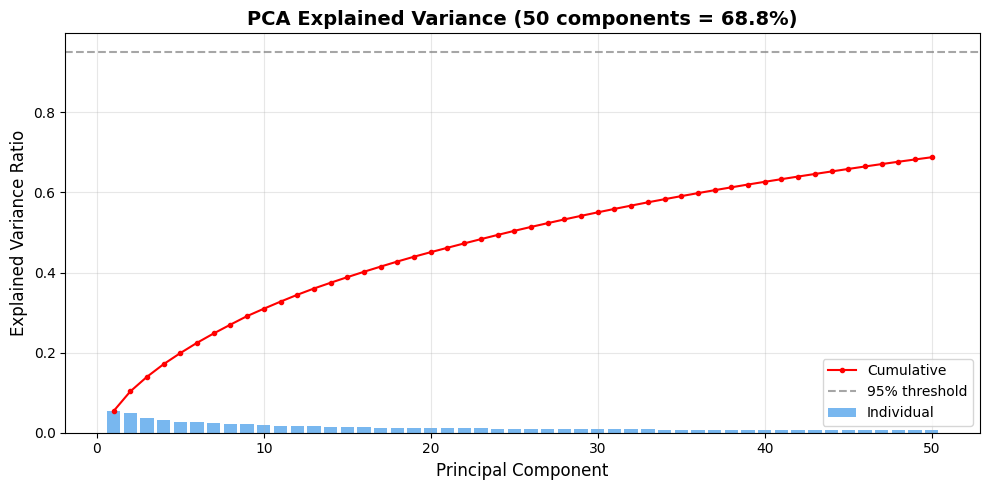

In [15]:
# ── PCA Explained Variance Plot ──────────────────────────────────────────────
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, N_PCA_COMPONENTS + 1), pca.explained_variance_ratio_,
       alpha=0.6, color='#1E88E5', label='Individual')
ax.plot(range(1, N_PCA_COMPONENTS + 1), cumulative_var,
        'r-o', markersize=3, label='Cumulative')
ax.axhline(y=0.95, color='gray', linestyle='--', alpha=0.7, label='95% threshold')
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_ylabel('Explained Variance Ratio', fontsize=12)
ax.set_title(f'PCA Explained Variance ({N_PCA_COMPONENTS} components = {explained_var*100:.1f}%)',
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('viz_pca_explained_variance.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── Combine PCA embeddings + hand-crafted features ───────────────────────────
X_train_combined = np.hstack([emb_train_pca, hc_train])
X_test_combined = np.hstack([emb_test_pca, hc_test])

feature_names = [f'PC_{i+1}' for i in range(N_PCA_COMPONENTS)] + hc_feature_names

print(f"Combined features: {N_PCA_COMPONENTS} PCA + {hc_train.shape[1]} hand-crafted = {X_train_combined.shape[1]} total")
print(f"X_train_combined: {X_train_combined.shape}")
print(f"X_test_combined:  {X_test_combined.shape}")
print(f"\nFeature-to-sample ratio: 1:{X_train_combined.shape[0] / X_train_combined.shape[1]:.1f}")

Combined features: 50 PCA + 18 hand-crafted = 68 total
X_train_combined: (376, 68)
X_test_combined:  (94, 68)

Feature-to-sample ratio: 1:5.5


In [17]:
# ── Scale combined features ──────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_combined)
X_test_scaled = scaler.transform(X_test_combined)

print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")
print(f"Post-scaling mean: {X_train_scaled.mean():.6f}  std: {X_train_scaled.std():.6f}")

X_train_scaled: (376, 68)
X_test_scaled:  (94, 68)
Post-scaling mean: -0.000000  std: 1.000000


---
## Step 5 — Train Ordinal XGBoost Classifier

**Key change from v1:** Instead of regression (`XGBRegressor`), we use **ordinal classification** (`XGBClassifier`) that predicts discrete score classes `{0, 1, 2, 3, 4}` ↔ `{0.0, 0.25, 0.50, 0.75, 1.0}`.

Advantages:
- Outputs are always valid scores (no rounding needed)
- Model learns class boundaries rather than continuous function
- Better calibrated for discrete ordinal targets

In [18]:
# ── Train MultiOutput Ordinal Classifier ─────────────────────────────────────
xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

multi_model = MultiOutputClassifier(estimator=xgb_base)
multi_model.fit(X_train_scaled, y_train_cls)

print("Model training complete.")
print(f"Sub-estimators: {len(multi_model.estimators_)} (one per dimension: D1, D2, D3, D5)")
print(f"Classes per estimator: {multi_model.estimators_[0].classes_}")

Model training complete.
Sub-estimators: 4 (one per dimension: D1, D2, D3, D5)
Classes per estimator: [0 1 2 3 4]


In [19]:
# ── Predict (class labels) & map back to scores ──────────────────────────────
y_pred_cls = multi_model.predict(X_test_scaled)

# Map class predictions → score values
y_pred_scores = np.vectorize(CLASS_TO_SCORE.get)(y_pred_cls).astype(float)

print(f"Predicted classes shape: {y_pred_cls.shape}")
print(f"Predicted scores shape:  {y_pred_scores.shape}")
print(f"\nPredicted score distribution:")
for i, dim in enumerate(['D1', 'D2', 'D3', 'D5']):
    unique, counts = np.unique(y_pred_scores[:, i], return_counts=True)
    print(f"  {dim}: {dict(zip(unique, counts))}")

# Preview
pred_df = pd.DataFrame(y_pred_scores, columns=['d1_pred', 'd2_pred', 'd3_pred', 'd5_pred'])
pred_df.head(10)

Predicted classes shape: (94, 4)
Predicted scores shape:  (94, 4)

Predicted score distribution:
  D1: {np.float64(0.0): np.int64(25), np.float64(0.25): np.int64(12), np.float64(0.5): np.int64(13), np.float64(0.75): np.int64(30), np.float64(1.0): np.int64(14)}
  D2: {np.float64(0.0): np.int64(2), np.float64(0.25): np.int64(21), np.float64(0.5): np.int64(33), np.float64(0.75): np.int64(29), np.float64(1.0): np.int64(9)}
  D3: {np.float64(0.0): np.int64(19), np.float64(0.25): np.int64(20), np.float64(0.5): np.int64(9), np.float64(0.75): np.int64(32), np.float64(1.0): np.int64(14)}
  D5: {np.float64(0.0): np.int64(36), np.float64(0.25): np.int64(29), np.float64(0.5): np.int64(21), np.float64(0.75): np.int64(8)}


,d1_pred,d2_pred,d3_pred,d5_pred
0,0.00,0.25,0.00,0.00
1,0.75,0.75,0.75,0.50
2,1.00,1.00,1.00,0.50
3,0.00,0.50,0.25,0.00
4,0.50,0.50,0.50,0.25
5,0.75,0.75,0.50,0.25
6,1.00,1.00,1.00,0.50
7,0.00,0.25,0.00,0.00
8,0.50,0.50,0.50,0.25
9,1.00,0.75,1.00,0.75


---
## Step 6 — Evaluation

### Per-dimension: MAE, RMSE, R² + per-dimension classification accuracy
### Tier: confusion matrix, classification report, overall accuracy

In [20]:
# ── Per-dimension metrics ────────────────────────────────────────────────────
dim_names = ['D1', 'D2', 'D3', 'D5']
metrics_results = {}

print("Per-Dimension Metrics (Test Set)")
print("=" * 65)
print(f"{'Dim':<5} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Accuracy':>10}")
print("-" * 65)

for i, dim in enumerate(dim_names):
    mae  = mean_absolute_error(y_test_scores[:, i], y_pred_scores[:, i])
    rmse = np.sqrt(mean_squared_error(y_test_scores[:, i], y_pred_scores[:, i]))
    r2   = r2_score(y_test_scores[:, i], y_pred_scores[:, i])
    acc  = accuracy_score(y_test_cls[:, i], y_pred_cls[:, i])
    metrics_results[dim] = {'MAE': mae, 'RMSE': rmse, 'R²': r2, 'Accuracy': acc}
    print(f"  {dim:<4} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f} {acc:>9.2%}")

print("=" * 65)

Per-Dimension Metrics (Test Set)
Dim        MAE     RMSE       R²   Accuracy
-----------------------------------------------------------------
  D1     0.0665   0.1610   0.8060    78.72%
  D2     0.1090   0.1877   0.4964    61.70%
  D3     0.0904   0.1786   0.7446    68.09%
  D5     0.0798   0.1631   0.5997    73.40%


In [21]:
# ── Tier prediction ──────────────────────────────────────────────────────────
test_df = df.loc[idx_test].copy().reset_index(drop=True)

# ACTUAL tier: ground-truth d1-d5 → complexity_score → get_tier
actual_complexity = test_df.apply(
    lambda r: complexity_score(r['d1'], r['d2'], r['d3'], r['d4'], r['d5']), axis=1
)
actual_tiers = actual_complexity.apply(get_tier)

# PREDICTED tier: predicted D1/D2/D3/D5 + d4_rule for D4
pred_d4_rule = test_df['d4_rule'].values
pred_complexity = np.array([
    complexity_score(
        y_pred_scores[i, 0], y_pred_scores[i, 1],
        y_pred_scores[i, 2], pred_d4_rule[i], y_pred_scores[i, 3]
    )
    for i in range(len(y_pred_scores))
])
pred_tiers = pd.Series(pred_complexity).apply(get_tier)

# Tier accuracy
tier_acc = accuracy_score(actual_tiers, pred_tiers)
print(f"\n*** Tier Accuracy: {tier_acc:.4f} ({tier_acc*100:.2f}%) ***")


*** Tier Accuracy: 0.7979 (79.79%) ***


In [22]:
# ── Confusion matrix & classification report ─────────────────────────────────
tier_labels = ['T1', 'T2', 'T3']

cm = confusion_matrix(actual_tiers, pred_tiers, labels=tier_labels)
print("Tier Confusion Matrix:")
print(pd.DataFrame(cm, index=tier_labels, columns=tier_labels))

print(f"\nClassification Report:")
print(classification_report(actual_tiers, pred_tiers, labels=tier_labels, zero_division=0))

Tier Confusion Matrix:
    T1  T2  T3
T1  36   1   1
T2   2  23   3
T3   0  12  16

Classification Report:
              precision    recall  f1-score   support

          T1       0.95      0.95      0.95        38
          T2       0.64      0.82      0.72        28
          T3       0.80      0.57      0.67        28

    accuracy                           0.80        94
   macro avg       0.80      0.78      0.78        94
weighted avg       0.81      0.80      0.80        94



---
## Step 7 — Reusable Inference Function

Self-contained function that processes a raw prompt through the full v2 pipeline.  
All models, scalers, and data are passed as parameters (no global state).

In [23]:
def profile_prompt(prompt_text, embed_model, pca, scaler, model,
                   df_train, X_train_emb_raw, phrasing_style=None):
    """
    Profile a single prompt through the Architecture 3 v2 pipeline.

    Parameters
    ----------
    prompt_text : str
        Raw prompt to profile.
    embed_model : SentenceTransformer
        Embedding model (all-MiniLM-L6-v2).
    pca : PCA
        Fitted PCA transformer.
    scaler : StandardScaler
        Fitted scaler for combined features.
    model : MultiOutputClassifier
        Trained multi-output ordinal classifier.
    df_train : pd.DataFrame
        Training dataframe (for similar prompt retrieval).
    X_train_emb_raw : np.ndarray
        Raw training embeddings (384d, for cosine similarity).
    phrasing_style : str, optional
        'explicit', 'implicit', or 'vague'. If None, inferred heuristically.

    Returns
    -------
    dict with predicted tier, scores, complexity, and similar prompts.
    """
    # 1. Embed
    emb_raw = embed_model.encode([prompt_text])

    # 2. PCA
    emb_pca = pca.transform(emb_raw)

    # 3. Hand-crafted features
    hc_feats = extract_handcrafted_features(prompt_text, phrasing_style)
    hc_array = np.array([list(hc_feats.values())])

    # 4. Combine & scale
    combined = np.hstack([emb_pca, hc_array])
    combined_scaled = scaler.transform(combined)

    # 5. Predict (ordinal classes → scores)
    pred_cls = model.predict(combined_scaled)
    d1_pred = CLASS_TO_SCORE[pred_cls[0][0]]
    d2_pred = CLASS_TO_SCORE[pred_cls[0][1]]
    d3_pred = CLASS_TO_SCORE[pred_cls[0][2]]
    d5_pred = CLASS_TO_SCORE[pred_cls[0][3]]

    # 6. D4 via rule engine
    d4_rule_val = get_d4(prompt_text)
    d4_final = d4_rule_val  # No KNN fallback in this architecture

    # 7. Complexity score & tier
    cs = complexity_score(d1_pred, d2_pred, d3_pred, d4_final, d5_pred)
    tier = get_tier(cs)

    # 8. Top 3 similar prompts (cosine similarity on raw embeddings)
    similarities = cosine_similarity(emb_raw, X_train_emb_raw)[0]
    top3_idx = np.argsort(similarities)[-3:][::-1]
    top3_prompts = df_train.iloc[top3_idx]['prompt'].tolist()
    top3_scores = similarities[top3_idx].tolist()

    return {
        'tier': tier,
        'tier_probabilities': round(float(cs), 4),
        'd1': d1_pred,
        'd2': d2_pred,
        'd3': d3_pred,
        'd4_rule': d4_rule_val,
        'd4_final': d4_final,
        'd5': d5_pred,
        'complexity_score': round(float(cs), 4),
        'top3_similar_prompts': [
            {'prompt': p, 'similarity': round(s, 4)}
            for p, s in zip(top3_prompts, top3_scores)
        ]
    }


print("Inference function defined.")

Inference function defined.


In [24]:
# ── Prepare training data for inference ──────────────────────────────────────
df_train = df.loc[idx_train].reset_index(drop=True)
X_train_emb_raw = emb_train  # Raw 384d embeddings for similarity search

print(f"df_train: {df_train.shape}")
print(f"X_train_emb_raw: {X_train_emb_raw.shape}")

df_train: (376, 14)
X_train_emb_raw: (376, 384)


In [25]:
# ── Test on 3 prompts ────────────────────────────────────────────────────────
test_prompts = [
    "why is our AWS bill so high this month",
    "build a full GenAI cost attribution platform with market research across AWS, Azure and GCP pricing",
    "set up SSO between okta and our internal tool"
]

for i, prompt in enumerate(test_prompts, 1):
    print(f"\n{'='*80}")
    print(f"TEST PROMPT {i}: \"{prompt}\"")
    print(f"{'='*80}")

    result = profile_prompt(
        prompt_text=prompt,
        embed_model=embed_model,
        pca=pca,
        scaler=scaler,
        model=multi_model,
        df_train=df_train,
        X_train_emb_raw=X_train_emb_raw
    )

    print(f"  Tier:             {result['tier']}")
    print(f"  Complexity Score: {result['complexity_score']}")
    print(f"  D1 (Scope):       {result['d1']}")
    print(f"  D2 (Specificity): {result['d2']}")
    print(f"  D3 (Cross-domain):{result['d3']}")
    print(f"  D4 (Rule-based):  {result['d4_rule']}")
    print(f"  D4 (Final):       {result['d4_final']}")
    print(f"  D5 (Output):      {result['d5']}")
    print(f"\n  Top 3 Similar Training Prompts:")
    for j, sim in enumerate(result['top3_similar_prompts'], 1):
        print(f"    {j}. [sim={sim['similarity']:.4f}] {sim['prompt'][:100]}...")


TEST PROMPT 1: "why is our AWS bill so high this month"
  Tier:             T1
  Complexity Score: 0.05
  D1 (Scope):       0.0
  D2 (Specificity): 0.25
  D3 (Cross-domain):0.0
  D4 (Rule-based):  0.0
  D4 (Final):       0.0
  D5 (Output):      0.0

  Top 3 Similar Training Prompts:
    1. [sim=0.7494] AWS bills are going crazy again and we have no idea who is spinning up these huge instances, someone...
    2. [sim=0.6388] costs keep creeping up, nobody knows who owns
what in aws, half the tags are wrong...
    3. [sim=0.6253] our cloud bill is double what it was last quarter and nobody can
explain it...

TEST PROMPT 2: "build a full GenAI cost attribution platform with market research across AWS, Azure and GCP pricing"
  Tier:             T1
  Complexity Score: 0.35
  D1 (Scope):       0.0
  D2 (Specificity): 0.75
  D3 (Cross-domain):0.25
  D4 (Rule-based):  1.0
  D4 (Final):       1.0
  D5 (Output):      0.0

  Top 3 Similar Training Prompts:
    1. [sim=0.5331] The executive board

---
## Step 8 — Visualizations

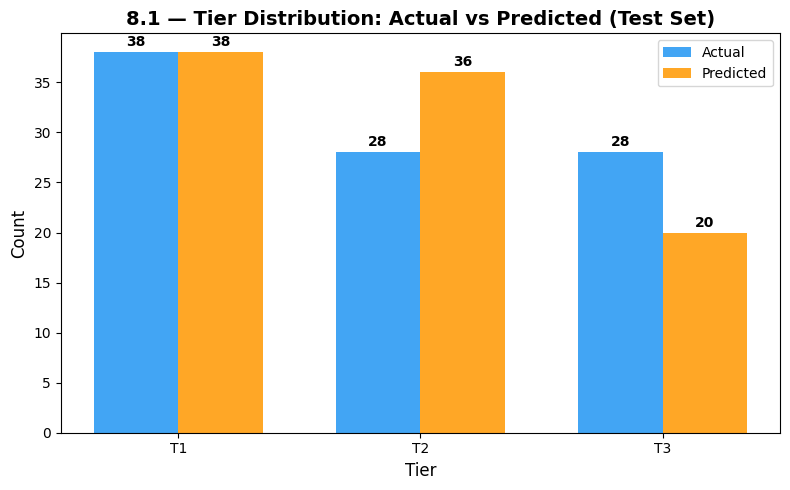

In [26]:
# ── 8.1 Tier Distribution: Actual vs Predicted ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

actual_counts = actual_tiers.value_counts().reindex(tier_labels, fill_value=0)
pred_counts = pred_tiers.value_counts().reindex(tier_labels, fill_value=0)

x = np.arange(len(tier_labels))
width = 0.35

bars1 = ax.bar(x - width/2, actual_counts.values, width, label='Actual', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, pred_counts.values, width, label='Predicted', color='#FF9800', alpha=0.85)

ax.set_xlabel('Tier', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('8.1 — Tier Distribution: Actual vs Predicted (Test Set)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(tier_labels)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('viz_8_1_tier_distribution_v2.png', dpi=150, bbox_inches='tight')
plt.show()

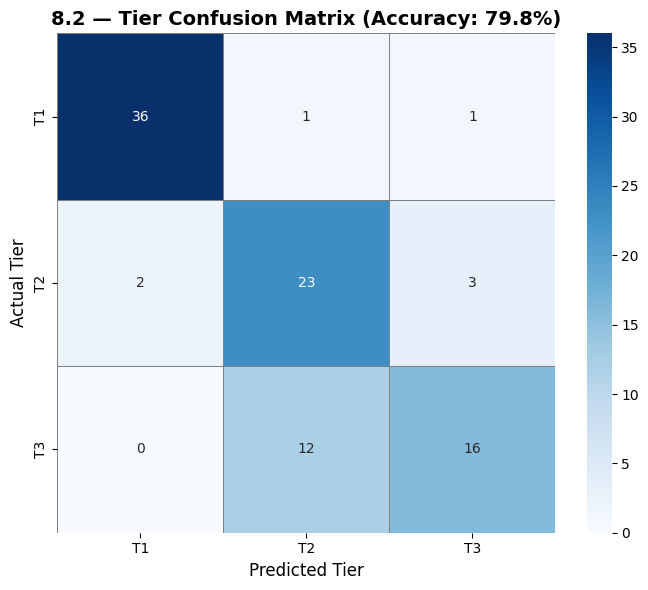

In [27]:
# ── 8.2 Confusion Matrix Heatmap ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=tier_labels, yticklabels=tier_labels,
            linewidths=0.5, linecolor='gray', ax=ax)

ax.set_xlabel('Predicted Tier', fontsize=12)
ax.set_ylabel('Actual Tier', fontsize=12)
ax.set_title(f'8.2 — Tier Confusion Matrix (Accuracy: {tier_acc*100:.1f}%)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('viz_8_2_confusion_matrix_v2.png', dpi=150, bbox_inches='tight')
plt.show()

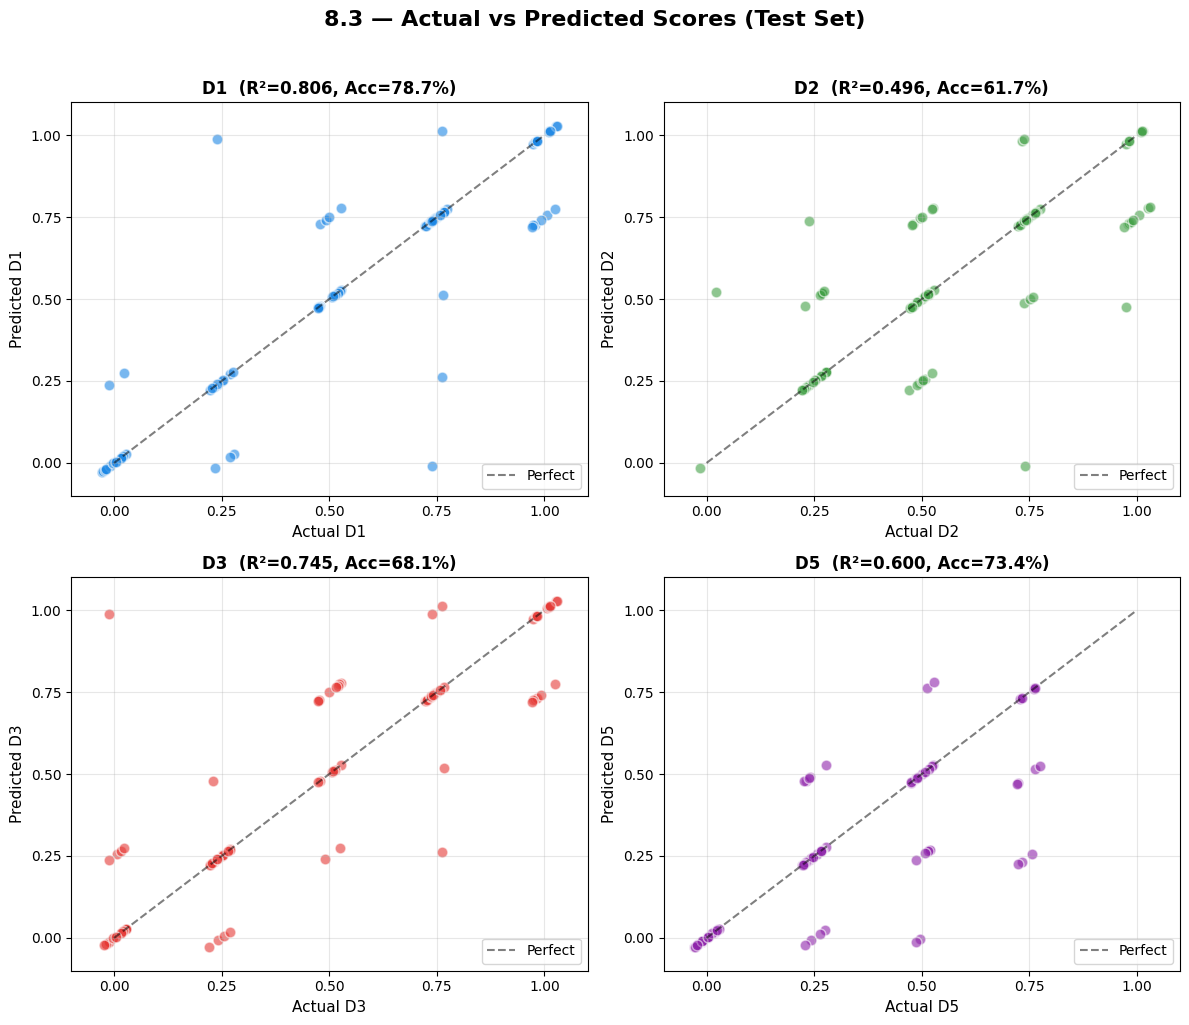

In [28]:
# ── 8.3 Actual vs Predicted Scatter Plots (2×2 grid) ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('8.3 — Actual vs Predicted Scores (Test Set)',
             fontsize=16, fontweight='bold', y=1.02)

colors = ['#1E88E5', '#43A047', '#E53935', '#8E24AA']

for i, (dim, color) in enumerate(zip(dim_names, colors)):
    ax = axes[i // 2][i % 2]

    # Add jitter for better visibility of overlapping points
    jitter = np.random.RandomState(42).uniform(-0.03, 0.03, size=len(y_test_scores))
    ax.scatter(y_test_scores[:, i] + jitter, y_pred_scores[:, i] + jitter,
              alpha=0.6, color=color, edgecolors='white', s=60)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1.5, label='Perfect')

    ax.set_xlabel(f'Actual {dim}', fontsize=11)
    ax.set_ylabel(f'Predicted {dim}', fontsize=11)
    ax.set_title(f'{dim}  (R²={metrics_results[dim]["R²"]:.3f}, Acc={metrics_results[dim]["Accuracy"]:.1%})',
                fontsize=12, fontweight='bold')
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(-0.1, 1.1)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viz_8_3_scatter_plots_v2.png', dpi=150, bbox_inches='tight')
plt.show()

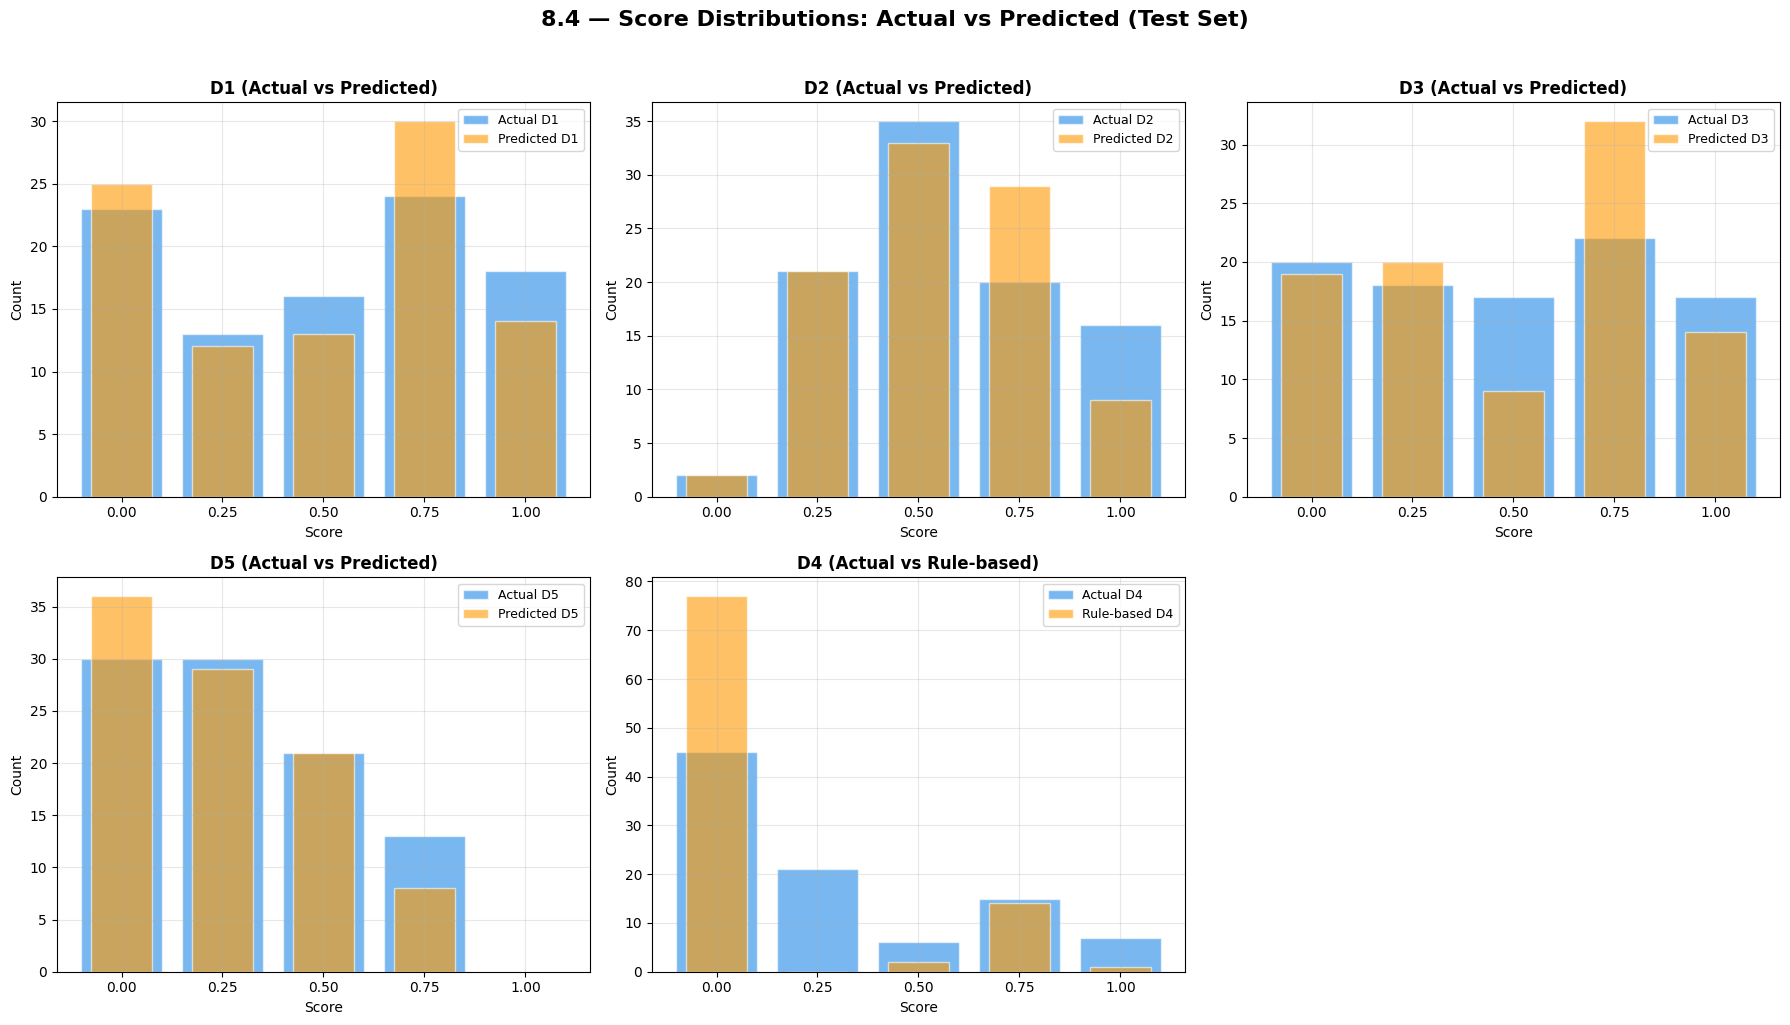

In [29]:
# ── 8.4 Distribution Plots: Actual vs Predicted/Rule-based ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('8.4 — Score Distributions: Actual vs Predicted (Test Set)',
             fontsize=16, fontweight='bold', y=1.02)

all_dims = ['D1', 'D2', 'D3', 'D5', 'D4']
plot_positions = [(0, 0), (0, 1), (0, 2), (1, 0), (1, 1)]
score_vals = [0, 0.25, 0.5, 0.75, 1.0]

for idx, (dim, pos) in enumerate(zip(all_dims, plot_positions)):
    ax = axes[pos[0]][pos[1]]

    if dim == 'D4':
        ax.hist(test_df['d4'], bins=np.arange(-0.125, 1.25, 0.25), alpha=0.6,
                label='Actual D4', color='#1E88E5', edgecolor='white', rwidth=0.8)
        ax.hist(test_df['d4_rule'], bins=np.arange(-0.125, 1.25, 0.25), alpha=0.6,
                label='Rule-based D4', color='#FF9800', edgecolor='white', rwidth=0.6)
        ax.set_title(f'{dim} (Actual vs Rule-based)', fontsize=12, fontweight='bold')
    else:
        ml_idx = ['D1', 'D2', 'D3', 'D5'].index(dim)
        ax.hist(y_test_scores[:, ml_idx], bins=np.arange(-0.125, 1.25, 0.25), alpha=0.6,
                label=f'Actual {dim}', color='#1E88E5', edgecolor='white', rwidth=0.8)
        ax.hist(y_pred_scores[:, ml_idx], bins=np.arange(-0.125, 1.25, 0.25), alpha=0.6,
                label=f'Predicted {dim}', color='#FF9800', edgecolor='white', rwidth=0.6)
        ax.set_title(f'{dim} (Actual vs Predicted)', fontsize=12, fontweight='bold')

    ax.set_xlabel('Score', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.set_xticks(score_vals)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[1][2].set_visible(False)

plt.tight_layout()
plt.savefig('viz_8_4_distribution_plots_v2.png', dpi=150, bbox_inches='tight')
plt.show()

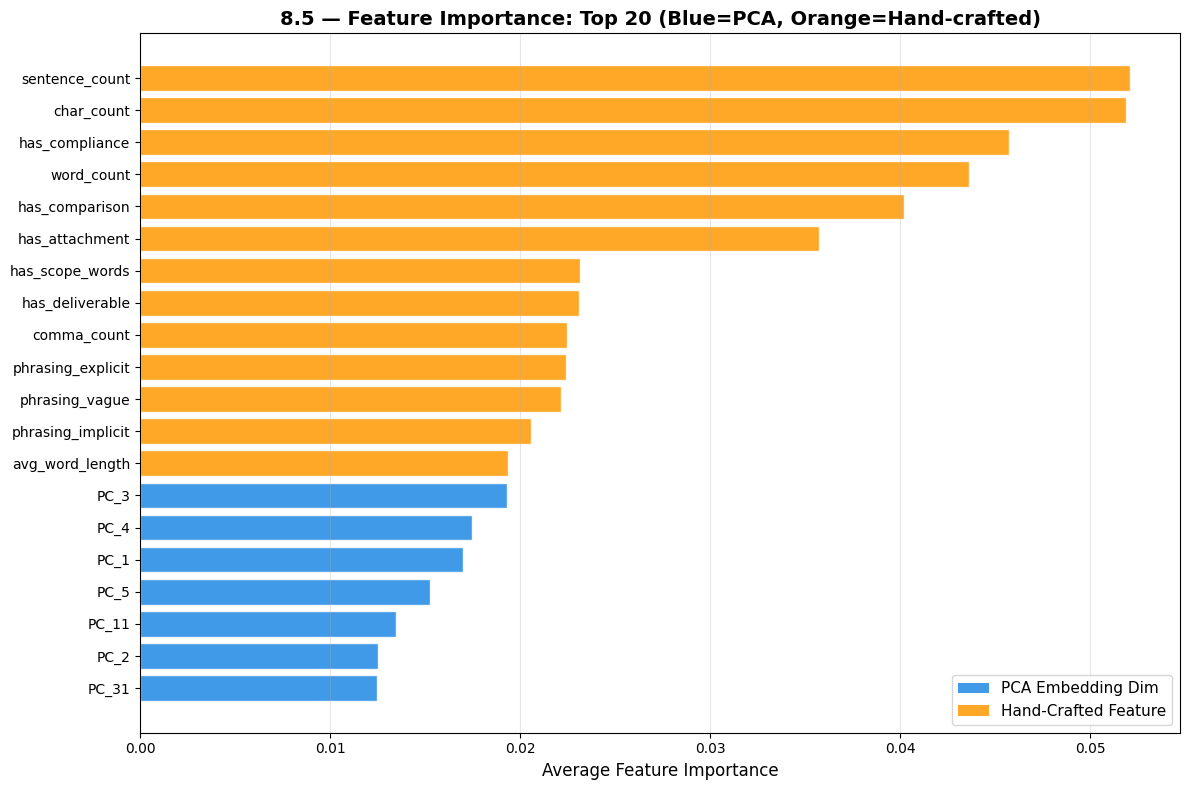


Hand-crafted feature importance ranking:
  sentence_count                 0.0521
  char_count                     0.0519
  has_compliance                 0.0457
  word_count                     0.0436
  has_comparison                 0.0402
  has_attachment                 0.0357
  has_scope_words                0.0232
  has_deliverable                0.0231
  comma_count                    0.0224
  phrasing_explicit              0.0224
  phrasing_vague                 0.0222
  phrasing_implicit              0.0205
  avg_word_length                0.0193
  has_market_terms               0.0123
  cloud_providers_mentioned      0.0119
  systems_mentioned              0.0112
  question_marks                 0.0085
  has_urgency                    0.0000


In [30]:
# ── 8.5 Feature Importance (Top 20 — PCA dims + hand-crafted features) ──────
importances = np.zeros(X_train_scaled.shape[1])
for est in multi_model.estimators_:
    importances += est.feature_importances_
importances /= len(multi_model.estimators_)

# Get top 20
top20_idx = np.argsort(importances)[-20:][::-1]
top20_vals = importances[top20_idx]
top20_labels = [feature_names[i] for i in top20_idx]

# Color-code: blue for PCA dims, orange for hand-crafted
bar_colors = ['#FF9800' if not lbl.startswith('PC_') else '#1E88E5' for lbl in top20_labels]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(range(len(top20_labels)), top20_vals[::-1],
               color=bar_colors[::-1], alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(top20_labels)))
ax.set_yticklabels(top20_labels[::-1], fontsize=10)
ax.set_xlabel('Average Feature Importance', fontsize=12)
ax.set_title('8.5 — Feature Importance: Top 20 (Blue=PCA, Orange=Hand-crafted)',
             fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1E88E5', alpha=0.85, label='PCA Embedding Dim'),
    Patch(facecolor='#FF9800', alpha=0.85, label='Hand-Crafted Feature')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('viz_8_5_feature_importance_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Print hand-crafted feature importance ranking
print("\nHand-crafted feature importance ranking:")
hc_start = N_PCA_COMPONENTS
hc_importances = importances[hc_start:]
hc_sorted = sorted(zip(hc_feature_names, hc_importances), key=lambda x: -x[1])
for name, imp in hc_sorted:
    print(f"  {name:<30s} {imp:.4f}")

---
## Step 9 — Model Persistence

Save all pipeline components for deployment.

In [31]:
# ── Save models ──────────────────────────────────────────────────────────────
joblib.dump(multi_model, 'xgb_multioutput_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(pca, 'pca_transformer.joblib')

print("Models saved:")
print("  → xgb_multioutput_model.joblib")
print("  → scaler.joblib")
print("  → pca_transformer.joblib")

Models saved:
  → xgb_multioutput_model.joblib
  → scaler.joblib
  → pca_transformer.joblib


In [32]:
# ── Final Summary Table ──────────────────────────────────────────────────────
print("\n" + "=" * 68)
print("     FINAL SUMMARY — Architecture 3 v2 (Enhanced) Results")
print("=" * 68)
print(f"{'Dimension':<12} {'MAE':>8} {'RMSE':>8} {'R²':>8} {'Accuracy':>10}")
print("-" * 68)

for dim in dim_names:
    m = metrics_results[dim]
    print(f"{dim:<12} {m['MAE']:>8.4f} {m['RMSE']:>8.4f} {m['R²']:>8.4f} {m['Accuracy']:>9.2%}")

print("-" * 68)
print(f"{'Tier Acc.':<12} {'':<8} {'':<8} {'':<8} {tier_acc:>9.2%}")
print(f"{'D4 Rule MAE':<12} {d4_mae:>8.4f}")
print("=" * 68)
print(f"\nImprovements applied:")
print(f"  ✓ PCA dimensionality reduction (384 → {N_PCA_COMPONENTS})")
print(f"  ✓ {len(hc_feature_names)} hand-crafted structural features")
print(f"  ✓ Ordinal classification (discrete score output)")
print(f"  ✓ Total feature count: {X_train_scaled.shape[1]} (vs 384 in v1)")
print(f"  ✓ Feature-to-sample ratio: 1:{X_train_combined.shape[0] / X_train_combined.shape[1]:.1f} (vs 1:1 in v1)")


     FINAL SUMMARY — Architecture 3 v2 (Enhanced) Results
Dimension         MAE     RMSE       R²   Accuracy
--------------------------------------------------------------------
D1             0.0665   0.1610   0.8060    78.72%
D2             0.1090   0.1877   0.4964    61.70%
D3             0.0904   0.1786   0.7446    68.09%
D5             0.0798   0.1631   0.5997    73.40%
--------------------------------------------------------------------
Tier Acc.                                  79.79%
D4 Rule MAE    0.2835

Improvements applied:
  ✓ PCA dimensionality reduction (384 → 50)
  ✓ 18 hand-crafted structural features
  ✓ Ordinal classification (discrete score output)
  ✓ Total feature count: 68 (vs 384 in v1)
  ✓ Feature-to-sample ratio: 1:5.5 (vs 1:1 in v1)


In [33]:
# ── Verify saved models load correctly ───────────────────────────────────────
loaded_model = joblib.load('xgb_multioutput_model.joblib')
loaded_scaler = joblib.load('scaler.joblib')
loaded_pca = joblib.load('pca_transformer.joblib')

# Quick verification
verify_emb_pca = loaded_pca.transform(emb_test[:1])
verify_combined = np.hstack([verify_emb_pca, hc_test[:1]])
verify_scaled = loaded_scaler.transform(verify_combined)
verify_pred = loaded_model.predict(verify_scaled)
verify_scores = [CLASS_TO_SCORE[c] for c in verify_pred[0]]

print(f"Model load verification — prediction on first test sample:")
print(f"  D1={verify_scores[0]}, D2={verify_scores[1]}, "
      f"D3={verify_scores[2]}, D5={verify_scores[3]}")
print(f"\n✅ Architecture 3 v2 pipeline complete!")

Model load verification — prediction on first test sample:
  D1=0.0, D2=0.25, D3=0.0, D5=0.0

✅ Architecture 3 v2 pipeline complete!
